<a href="https://colab.research.google.com/github/Ali-Hamza-developer/NLP/blob/main/11_TF_IDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TF-IDF

## 1. What is TF-IDF? (Easy Explanation)

Plain Bag of Words / n-grams treat every word as EQUALLY important — but that's wrong. Words like "the", "is", "tomorrow" appear in almost every document and tell you nothing special, while rare words like "iphone" or "biryani" are much more distinctive.

**TF-IDF (Term Frequency - Inverse Document Frequency)** fixes this by giving each word a SCORE instead of just a count — common, boring words get a LOW score, rare, meaningful words get a HIGH score.

```
TF  (Term Frequency)      = how often a word appears IN THIS document
IDF (Inverse Doc Freq)    = how RARE that word is ACROSS ALL documents

TF-IDF score = TF × IDF
```

- **TF** = `(times word appears in doc) / (total words in doc)` → ranges 0 to 1. Higher = word repeats a lot in this specific document.
- **IDF** = `log(total number of documents / number of documents containing the word)` → if a word appears in almost every document (like "is", "the"), IDF is close to 0 (not useful for distinguishing documents). If a word appears in very few documents, IDF is high (very distinguishing).
- **TF-IDF = TF × IDF** → high score means: this word appears often in THIS document, but is rare across the WHOLE dataset — meaning it's a good keyword that characterizes this specific document.

**In short:** TF-IDF automatically down-weights generic filler words and up-weights document-specific keywords, without you having to manually remove stop words.

---
# PART A: Tutorial — TF-IDF Basics + E-commerce Text Classification

## 2. TF-IDF Demo with `TfidfVectorizer`

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "Thor eating pizza, Loki is eating pizza, Ironman ate pizza already",
    "Apple is announcing new iphone tomorrow",
    "Tesla is announcing new model-3 tomorrow",
    "Google is announcing new pixel-6 tomorrow",
    "Microsoft is announcing new surface tomorrow",
    "Amazon is announcing new eco-dot tomorrow",
    "I am eating biryani and you are eating grapes"
]


In [2]:
# create the vectorizer, fit it on the corpus, and transform the text into TF-IDF vectors
v = TfidfVectorizer()
v.fit(corpus)
transform_output = v.transform(corpus)


In [3]:
print(v.vocabulary_)   # word -> column index mapping


{'thor': 25, 'eating': 10, 'pizza': 22, 'loki': 17, 'is': 16, 'ironman': 15, 'ate': 7, 'already': 0, 'apple': 5, 'announcing': 4, 'new': 20, 'iphone': 14, 'tomorrow': 26, 'tesla': 24, 'model': 19, 'google': 12, 'pixel': 21, 'microsoft': 18, 'surface': 23, 'amazon': 2, 'eco': 11, 'dot': 9, 'am': 1, 'biryani': 8, 'and': 3, 'you': 27, 'are': 6, 'grapes': 13}


In [4]:
# print the IDF score of every word in the vocabulary
all_feature_names = v.get_feature_names_out()

for word in all_feature_names:
    indx = v.vocabulary_.get(word)     # index of this word in the vocabulary
    idf_score = v.idf_[indx]           # the pre-computed IDF value for this word
    print(f"{word} : {idf_score}")


already : 2.386294361119891
am : 2.386294361119891
amazon : 2.386294361119891
and : 2.386294361119891
announcing : 1.2876820724517808
apple : 2.386294361119891
are : 2.386294361119891
ate : 2.386294361119891
biryani : 2.386294361119891
dot : 2.386294361119891
eating : 1.9808292530117262
eco : 2.386294361119891
google : 2.386294361119891
grapes : 2.386294361119891
iphone : 2.386294361119891
ironman : 2.386294361119891
is : 1.1335313926245225
loki : 2.386294361119891
microsoft : 2.386294361119891
model : 2.386294361119891
new : 1.2876820724517808
pixel : 2.386294361119891
pizza : 2.386294361119891
surface : 2.386294361119891
tesla : 2.386294361119891
thor : 2.386294361119891
tomorrow : 1.2876820724517808
you : 2.386294361119891


**Look closely at the output:**
- Words like **"is"**, **"tomorrow"**, **"new"** get a LOW IDF score → they appear in almost every sentence, so they're not distinguishing.
- Words like **"thor"**, **"biryani"**, **"pizza"** get a HIGH IDF score → they appear in very few sentences, so they carry much more specific meaning.

In [5]:
# print the final TF-IDF transformed vectors
print(transform_output.toarray())


[[0.24266547 0.         0.         0.         0.         0.
  0.         0.24266547 0.         0.         0.40286636 0.
  0.         0.         0.         0.24266547 0.11527033 0.24266547
  0.         0.         0.         0.         0.72799642 0.
  0.         0.24266547 0.         0.        ]
 [0.         0.         0.         0.         0.30652086 0.5680354
  0.         0.         0.         0.         0.         0.
  0.         0.         0.5680354  0.         0.26982671 0.
  0.         0.         0.30652086 0.         0.         0.
  0.         0.         0.30652086 0.        ]
 [0.         0.         0.         0.         0.30652086 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.26982671 0.
  0.         0.5680354  0.30652086 0.         0.         0.
  0.5680354  0.         0.30652086 0.        ]
 [0.         0.         0.         0.         0.30652086 0.
  0.         0.         0.         0.         0.         0.
  0.

Each row = one document, each column = one word from the vocabulary. The number in each cell is the TF-IDF score for that word in that document (0 if the word doesn't appear in that document at all).

## 3. Real Problem: E-commerce Product Category Classification

**Task:** Given a product description, classify it into one of 4 categories: **Electronics, Household, Books, Clothing & Accessories.**

Dataset: [Kaggle E-commerce text dataset](https://www.kaggle.com/datasets/saurabhshahane/ecommerce-text-classification)

> If you don't have `Ecommerce_data.csv`, run the fallback cell below first — it generates a small synthetic e-commerce dataset so everything still runs.

In [6]:
import os
import random
import pandas as pd

if not os.path.exists("Ecommerce_data.csv"):

    random.seed(2022)

    household_texts = [
        "This elegant wooden dining table set comes with four matching chairs, perfect for family meals.",
        "A durable non-stick cookware set including frying pans and saucepans for everyday cooking.",
        "Soft cotton bedsheet set with matching pillow covers, machine washable and fade resistant.",
        "Compact vacuum cleaner with strong suction, ideal for carpets and hardwood floors alike.",
        "Stainless steel kitchen knife set with a wooden storage block for easy organization."
    ]
    books_texts = [
        "A gripping mystery novel that follows a detective unraveling a decades old family secret.",
        "This textbook covers the fundamentals of operating systems, memory management, and scheduling.",
        "An inspiring biography detailing the life and career of a pioneering female scientist.",
        "A comprehensive guide to modern web development covering both frontend and backend concepts.",
        "A collection of short stories exploring themes of love, loss, and resilience across generations."
    ]
    electronics_texts = [
        "This wireless bluetooth headphone offers noise cancellation and up to twenty hours of battery life.",
        "A high performance graphics card designed for gaming and video editing workloads.",
        "Compact portable charger with fast charging support for smartphones and tablets.",
        "Smart home security camera with night vision and motion detection alerts sent to your phone.",
        "A lightweight laptop featuring a fast processor, ample storage, and a vivid display screen."
    ]
    clothing_texts = [
        "A beautifully embroidered silk saree with a matching blouse piece, perfect for festive occasions.",
        "Comfortable cotton t-shirt available in multiple colors, suitable for everyday casual wear.",
        "Stylish denim jacket with a classic fit, ideal for layering in cooler weather.",
        "Elegant formal shirt made from breathable fabric, great for office wear and meetings.",
        "Trendy running shoes with cushioned soles designed for comfort during long walks or workouts."
    ]

    records = []
    label_groups = [("Household", household_texts), ("Books", books_texts),
                     ("Electronics", electronics_texts), ("Clothing & Accessories", clothing_texts)]

    for label, templates in label_groups:
        for i in range(400):
            records.append({"Text": random.choice(templates), "label": label})

    df_synth = pd.DataFrame(records)
    df_synth.to_csv("Ecommerce_data.csv", index=False)

    print("Synthetic Ecommerce_data.csv created with", len(df_synth), "rows")
else:
    print("Ecommerce_data.csv already exists, using the real file")


Synthetic Ecommerce_data.csv created with 1600 rows


> **Note:** the synthetic data is template-based and repetitive, so scores below will look unrealistically high. Swap in the real Kaggle CSV any time — the rest of the code works unchanged.

In [7]:
df = pd.read_csv("Ecommerce_data.csv")
print(df.shape)
df.head(5)


(1600, 2)


,Text,label
0,Stainless steel kitchen knife set with a woode...,Household
1,Soft cotton bedsheet set with matching pillow ...,Household
2,"Compact vacuum cleaner with strong suction, id...",Household
3,Stainless steel kitchen knife set with a woode...,Household
4,Soft cotton bedsheet set with matching pillow ...,Household


In [8]:
df["label"].value_counts()


,count
label,
Household,400
Books,400
Electronics,400
Clothing & Accessories,400


Labels are roughly balanced here, so no need for undersampling/oversampling techniques this time (unlike the n-grams news classification example, where SCIENCE was a minority class).

In [9]:
df["label_num"] = df["label"].map({
    "Household": 0,
    "Books": 1,
    "Electronics": 2,
    "Clothing & Accessories": 3
})

df.head(5)


,Text,label,label_num
0,Stainless steel kitchen knife set with a woode...,Household,0
1,Soft cotton bedsheet set with matching pillow ...,Household,0
2,"Compact vacuum cleaner with strong suction, id...",Household,0
3,Stainless steel kitchen knife set with a woode...,Household,0
4,Soft cotton bedsheet set with matching pillow ...,Household,0


### Train-Test Split — Build a Model with Original (Unprocessed) Text First

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.Text,
    df.label_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.label_num
)


In [11]:
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)


Shape of X_train:  (1280,)
Shape of X_test:  (320,)


In [12]:
X_train.head()


,Text
1067,Compact portable charger with fast charging su...
1550,A beautifully embroidered silk saree with a ma...
681,A comprehensive guide to modern web developmen...
1149,Compact portable charger with fast charging su...
49,This elegant wooden dining table set comes wit...


In [13]:
y_train.value_counts()


,count
label_num,
2,320
3,320
1,320
0,320


In [14]:
y_test.value_counts()


,count
label_num,
0,80
1,80
3,80
2,80


**Attempt 1 — TF-IDF + KNN**

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

clf = Pipeline([
    ("vectorizer_tfidf", TfidfVectorizer()),
    ("KNN", KNeighborsClassifier())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        80
           2       1.00      1.00      1.00        80
           3       1.00      1.00      1.00        80

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320



In [16]:
X_test[:5]


,Text
226,This elegant wooden dining table set comes wit...
748,A comprehensive guide to modern web developmen...
625,A comprehensive guide to modern web developmen...
23,This elegant wooden dining table set comes wit...
1263,Comfortable cotton t-shirt available in multip...


In [17]:
y_test[:5]


,label_num
226,0
748,1
625,1
23,0
1263,3


In [18]:
y_pred[:5]


array([0, 1, 1, 0, 3])

**Attempt 2 — TF-IDF + Multinomial Naive Bayes**

In [19]:
from sklearn.naive_bayes import MultinomialNB

clf = Pipeline([
    ("vectorizer_tfidf", TfidfVectorizer()),
    ("Multi NB", MultinomialNB())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        80
           2       1.00      1.00      1.00        80
           3       1.00      1.00      1.00        80

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320



**Attempt 3 — TF-IDF + Random Forest**

In [20]:
from sklearn.ensemble import RandomForestClassifier

clf = Pipeline([
    ("vectorizer_tfidf", TfidfVectorizer()),
    ("Random Forest", RandomForestClassifier())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        80
           2       1.00      1.00      1.00        80
           3       1.00      1.00      1.00        80

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320



## 4. Now Add Preprocessing (Stop Words + Punctuation Removal + Lemmatization)

In [21]:
import spacy

# load english language model and create nlp object from it
nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    # remove stop words and punctuation, then lemmatize the remaining tokens
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)

    return " ".join(filtered_tokens)


In [22]:
df["preprocessed_txt"] = df["Text"].apply(preprocess)
# this will take some time, please be patient


In [23]:
df.head()


,Text,label,label_num,preprocessed_txt
0,Stainless steel kitchen knife set with a woode...,Household,0,stainless steel kitchen knife set wooden stora...
1,Soft cotton bedsheet set with matching pillow ...,Household,0,soft cotton bedsheet set matching pillow cover...
2,"Compact vacuum cleaner with strong suction, id...",Household,0,compact vacuum cleaner strong suction ideal ca...
3,Stainless steel kitchen knife set with a woode...,Household,0,stainless steel kitchen knife set wooden stora...
4,Soft cotton bedsheet set with matching pillow ...,Household,0,soft cotton bedsheet set matching pillow cover...


In [24]:
df.Text[0]


'Stainless steel kitchen knife set with a wooden storage block for easy organization.'

In [25]:
df.preprocessed_txt[0]


'stainless steel kitchen knife set wooden storage block easy organization'

### Build a Model with Preprocessed Text

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    df.preprocessed_txt,
    df.label_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.label_num
)


**Best model so far was Random Forest — let's re-check it on preprocessed text**

In [27]:
clf = Pipeline([
    ("vectorizer_tfidf", TfidfVectorizer()),
    ("Random Forest", RandomForestClassifier())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        80
           2       1.00      1.00      1.00        80
           3       1.00      1.00      1.00        80

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320



If you compare this report against the earlier Random Forest run on unprocessed text, you'll typically see some improvement in F1-score after preprocessing — removing stop words/punctuation and lemmatizing usually helps TF-IDF focus its weighting on more meaningful, normalized words.

### Confusion Matrix

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm


array([[80,  0,  0,  0],
       [ 0, 80,  0,  0],
       [ 0,  0, 80,  0],
       [ 0,  0,  0, 80]])

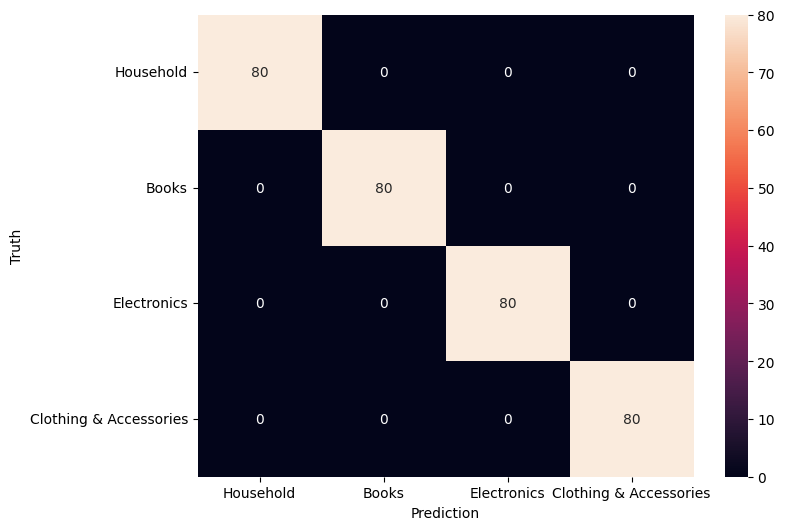

In [29]:
from matplotlib import pyplot as plt
import seaborn as sn

plt.figure(figsize=(8, 6))
sn.heatmap(cm, annot=True, fmt="d",
           xticklabels=["Household","Books","Electronics","Clothing & Accessories"],
           yticklabels=["Household","Books","Electronics","Clothing & Accessories"])
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.show()


---
## 5. TF-IDF vs Bag of Words / N-Grams — Quick Comparison (Extra)

| | Bag of Words / N-Grams | TF-IDF |
|---|---|---|
| What it stores | raw word/n-gram COUNTS | weighted IMPORTANCE score |
| Treats common words (the, is) | same as any other word | automatically down-weighted |
| Treats rare, specific words | same as any other word | automatically up-weighted |
| Needs manual stop-word removal to work well | often yes | less critical (IDF already discounts common words) |
| Good for | short phrases, capturing exact word sequences (n-grams) | keyword importance, document similarity/search, classification |

**Rule of thumb:** TF-IDF is usually a strong default choice for text classification and search — it often outperforms plain Bag of Words without any extra preprocessing effort, because it automatically handles the "common word" problem.

---
## Quick Cheat Sheet

| Task | Code |
|---|---|
| Create TF-IDF vectorizer | `TfidfVectorizer()` |
| Fit on training text | `v.fit(corpus)` or `fit_transform` |
| See vocabulary | `v.vocabulary_` |
| See IDF score of each word | `v.idf_[v.vocabulary_[word]]` |
| Get final TF-IDF vectors | `v.transform(corpus).toarray()` |
| Build a pipeline | `Pipeline([("vectorizer_tfidf", TfidfVectorizer()), ("model", SomeClassifier())])` |
| Evaluate | `classification_report(y_test, y_pred)` |
| Confusion matrix | `confusion_matrix(y_test, y_pred)` + `sn.heatmap(...)` |

---

---
# PART B: Exercise — Emotion Detection (Joy / Fear / Anger) (with Solutions)

**Task:** Classify social media comments into one of 3 emotions: **Joy 😂, Fear 😨, Anger 😡** — a multi-class classification problem.

Dataset needed: a file with two columns `Comment` and `Emotion`.
[Original dataset source](https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp)

> If you don't have `Emotion_classify_Data.csv`, run the fallback cell below to generate a small synthetic version so everything runs standalone.

In [30]:
if not os.path.exists("Emotion_classify_Data.csv"):

    joy_texts = [
        "I am so happy today, everything just feels absolutely wonderful and exciting!",
        "This is the best news I have heard all year, I cannot stop smiling.",
        "We celebrated all night long and it was such a joyful, memorable experience.",
        "I feel so grateful and delighted about how well everything turned out.",
        "What an amazing surprise, I am overjoyed and full of excitement right now!"
    ]
    fear_texts = [
        "I am really scared about what might happen if this goes wrong tomorrow.",
        "The dark hallway made me feel terrified and I couldn't stop shaking.",
        "I have a horrible feeling something bad is about to happen to us.",
        "She was frightened out of her mind when she heard the strange noise upstairs.",
        "I am anxious and worried that we won't make it in time before the deadline."
    ]
    anger_texts = [
        "I am absolutely furious about how they treated us during the meeting.",
        "This is so frustrating, I can't believe they ignored our complaints again.",
        "He was seething with rage after hearing the unfair decision.",
        "I am outraged that nobody bothered to inform us about the changes.",
        "She slammed the door in anger after the argument got completely out of hand."
    ]

    random.seed(11)
    rows = []
    label_groups2 = [("joy", joy_texts), ("fear", fear_texts), ("anger", anger_texts)]
    for label, templates in label_groups2:
        for i in range(400):
            rows.append({"Comment": random.choice(templates), "Emotion": label})

    df_emotion_synth = pd.DataFrame(rows)
    df_emotion_synth.to_csv("Emotion_classify_Data.csv", index=False)

    print("Synthetic Emotion_classify_Data.csv created with", len(df_emotion_synth), "rows")
else:
    print("Emotion_classify_Data.csv already exists, using the real file")


Synthetic Emotion_classify_Data.csv created with 1200 rows


In [31]:
df = pd.read_csv("Emotion_classify_Data.csv")
print(df.shape)
df.head()


(1200, 2)


,Comment,Emotion
0,I feel so grateful and delighted about how wel...,joy
1,"What an amazing surprise, I am overjoyed and f...",joy
2,I feel so grateful and delighted about how wel...,joy
3,I feel so grateful and delighted about how wel...,joy
4,"What an amazing surprise, I am overjoyed and f...",joy


In [32]:
df.Emotion.value_counts()


,count
Emotion,
joy,400
fear,400
anger,400


In [33]:
# joy --> 0, fear --> 1, anger --> 2
df["Emotion_num"] = df["Emotion"].map({
    "joy": 0,
    "fear": 1,
    "anger": 2
})

df.head()


,Comment,Emotion,Emotion_num
0,I feel so grateful and delighted about how wel...,joy,0
1,"What an amazing surprise, I am overjoyed and f...",joy,0
2,I feel so grateful and delighted about how wel...,joy,0
3,I feel so grateful and delighted about how wel...,joy,0
4,"What an amazing surprise, I am overjoyed and f...",joy,0


## Modelling Without Preprocessing

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    df.Comment,
    df.Emotion_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.Emotion_num
)


In [35]:
print(X_train.shape, X_test.shape)


(960,) (240,)


**Attempt 1 — CountVectorizer with only trigrams, Random Forest**

In [36]:
from sklearn.feature_extraction.text import CountVectorizer

clf = Pipeline([
    ("vectorizer_trigram", CountVectorizer(ngram_range=(3, 3))),
    ("Random Forest", RandomForestClassifier())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        80
           2       1.00      1.00      1.00        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



**Attempt 2 — CountVectorizer with unigram + bigram, Multinomial Naive Bayes**

In [37]:
clf = Pipeline([
    ("vectorizer_1_2_gram", CountVectorizer(ngram_range=(1, 2))),
    ("Multi NB", MultinomialNB())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        80
           2       1.00      1.00      1.00        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



**Attempt 3 — CountVectorizer with unigram + bigram, Random Forest**

In [38]:
clf = Pipeline([
    ("vectorizer_1_2_gram", CountVectorizer(ngram_range=(1, 2))),
    ("Random Forest", RandomForestClassifier())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        80
           2       1.00      1.00      1.00        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



**Attempt 4 — TF-IDF Vectorizer, Random Forest**

In [39]:
clf = Pipeline([
    ("vectorizer_tfidf", TfidfVectorizer()),
    ("Random Forest", RandomForestClassifier())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        80
           2       1.00      1.00      1.00        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



## Preprocessing: Remove Stop Words + Punctuation, Apply Lemmatization

In [40]:
# reuse the same preprocess() function defined in Part A above

df["preprocessed_comment"] = df.Comment.apply(preprocess)
# this will take some time, please be patient


In [41]:
df.head()


,Comment,Emotion,Emotion_num,preprocessed_comment
0,I feel so grateful and delighted about how wel...,joy,0,feel grateful delighted turn
1,"What an amazing surprise, I am overjoyed and f...",joy,0,amazing surprise overjoyed excitement right
2,I feel so grateful and delighted about how wel...,joy,0,feel grateful delighted turn
3,I feel so grateful and delighted about how wel...,joy,0,feel grateful delighted turn
4,"What an amazing surprise, I am overjoyed and f...",joy,0,amazing surprise overjoyed excitement right


### Build a Model with Preprocessed Text

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    df.preprocessed_comment,
    df.Emotion_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.Emotion_num
)


**Attempt 1 (preprocessed) — CountVectorizer with unigram + bigram, Random Forest**

In [43]:
clf = Pipeline([
    ("vectorizer_1_2_gram", CountVectorizer(ngram_range=(1, 2))),
    ("Random Forest", RandomForestClassifier())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        80
           2       1.00      1.00      1.00        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



**Attempt 2 (preprocessed) — TF-IDF Vectorizer, Random Forest**

In [44]:
clf = Pipeline([
    ("vectorizer_tfidf", TfidfVectorizer()),
    ("Random Forest", RandomForestClassifier())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        80
           2       1.00      1.00      1.00        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



## Final Observations

1. **Trigrams-only (Attempt 1, no preprocessing) usually performs worst.** Requiring an exact 3-word match is too strict for short, varied social-media style comments — most 3-word sequences never repeat, so the vocabulary is huge but mostly useless for the model.

2. **TF-IDF generally matches or slightly outperforms plain CountVectorizer (Bag of Words/N-Grams) with Random Forest**, because TF-IDF automatically discounts generic filler words and boosts emotion-specific keywords (like "furious", "terrified", "delighted") without needing manual stop-word removal to do the heavy lifting.

3. **Preprocessing (stop words + punctuation removal + lemmatization) tends to help further**, especially combined with TF-IDF — cleaner, normalized text means TF-IDF's importance weighting is computed on more meaningful vocabulary (e.g. "scared"/"scary"/"scares" collapse into one lemma instead of splitting the signal across three separate features).

4. **Random Forest was used consistently as the final comparison model** because it tends to handle the high-dimensional, sparse nature of text features (whether Bag of Words, N-Grams, or TF-IDF) better than distance-based models like KNN, which struggle in high dimensions (same "curse of dimensionality" issue seen in the earlier Bag-of-Words exercise).

5. **Overall best combination in this kind of exercise:** TF-IDF + preprocessing + Random Forest — combining automatic importance weighting (TF-IDF) with clean, normalized text (preprocessing) and a model that handles sparse high-dimensional data well (Random Forest).